In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

ZIP_PATH = 'drive/MyDrive/Task2.zip'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("projem")
os.chdir("projem") 

In [3]:
!ls

drive  projem  sample_data


In [1]:
import sys
sys.path.append('projem/Task2')

from preprocess import JetEventDataset
import torch
import pickle
from torch_geometric.transforms import NormalizeFeatures
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader
from gnn_model import GenericGNN
import torch.nn as nn

In [2]:
import random
import numpy as np

def set_all_seeds(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    g = torch.Generator()
    g.manual_seed(seed)

    return g

In [ ]:
ROOT_DIR = 'projem/Task2/Dataset/Data'
g = set_all_seeds(42)
VAL_SPLIT = 0.20
TEST_SPLIT = 0.10
BATCH_SIZE = 128
NUM_WORKERS = 6
DEVICE = 'cuda'

In [ ]:
dataset = JetEventDataset(root=ROOT_DIR, pre_transform=NormalizeFeatures(), k=5)

labels = [int(data.y) for data in dataset]
indices = list(range(len(dataset)))

train_indices, test_indices, _, _ = train_test_split(indices, labels, test_size=TEST_SPLIT, random_state=42, stratify=labels)
train_indices, val_indices, _, _ = train_test_split(train_indices, [labels[i] for i in train_indices], test_size=VAL_SPLIT, random_state=42, stratify=[labels[i] for i in train_indices])

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

del dataset

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=g)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, generator=g)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, generator=g)

Processing...


In [10]:
model = GenericGNN(
    in_channels=3,
    hidden_channels=256,
    num_layers=4,
    num_classes=1,
    conv_type="sage",
    pooling="mean",
    dropout=0.3,
    residual=True
)

In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheculer = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [12]:
labels_count = {}
for label in labels:
    if label not in labels_count:
        labels_count[label] = 0
    labels_count[label] += 1

print(f"Class distribution: {labels_count}")

Class distribution: {0: 69653, 1: 69653}


In [14]:
from projem.Task2.train_gnnModel import train_model
best_value = train_model(model, train_loader, val_loader, DEVICE, criterion, optimizer, early_stopping_patience=10, EPOCHS=100, scheduler=scheculer)

INFO:app_logger:Starting training for 100 epochs
INFO:app_logger:
Epoch 1/100
INFO:app_logger:---------------


Epoch 1/100 - Training:   0%|          | 0/784 [00:00<?, ?it/s]

INFO:app_logger:Batch 10: Loss = 0.6618
INFO:app_logger:Batch 20: Loss = 0.6234
INFO:app_logger:Batch 30: Loss = 0.6146
INFO:app_logger:Batch 40: Loss = 0.5426
INFO:app_logger:Batch 50: Loss = 0.5703
INFO:app_logger:Batch 60: Loss = 0.6122
INFO:app_logger:Batch 70: Loss = 0.5933
INFO:app_logger:Batch 80: Loss = 0.5627
INFO:app_logger:Batch 90: Loss = 0.6239
INFO:app_logger:Batch 100: Loss = 0.6006
INFO:app_logger:Batch 110: Loss = 0.6475
INFO:app_logger:Batch 120: Loss = 0.5542
INFO:app_logger:Batch 130: Loss = 0.5891
INFO:app_logger:Batch 140: Loss = 0.5748
INFO:app_logger:Batch 150: Loss = 0.5493
INFO:app_logger:Batch 160: Loss = 0.6275
INFO:app_logger:Batch 170: Loss = 0.5190
INFO:app_logger:Batch 180: Loss = 0.6924
INFO:app_logger:Batch 190: Loss = 0.6176
INFO:app_logger:Batch 200: Loss = 0.5958
INFO:app_logger:Batch 210: Loss = 0.5578
INFO:app_logger:Batch 220: Loss = 0.5890
INFO:app_logger:Batch 230: Loss = 0.5941
INFO:app_logger:Batch 240: Loss = 0.6116
INFO:app_logger:Batch 250

Epoch 1/100 - Validation:   0%|          | 0/196 [00:00<?, ?it/s]

INFO:app_logger:Current Learning Rate: 0.001000
INFO:app_logger:Epoch 1 completed - Train Loss: 0.5829, Train_Acc: 0.7026, Train_AUC: 0.7654, F1_train: 0.7026, Val Loss: 0.6482, Val_F1: 0.5647, Val_Acc: 0.6126, Val_AUC: 0.7709
INFO:app_logger:Confusion Matrix:
[[11842, 695], [9018, 3520]]
TP: 3520, TN: 11842, FP: 695, FN: 9018 | Precision: 0.8351, Recall: 0.2807, Specificity: 0.9446
INFO:app_logger: Validation loss improved. Model saved to best_model.pth
INFO:app_logger:
Epoch 2/100
INFO:app_logger:---------------


...

Epoch 24/100 - Training:   0%|          | 0/784 [00:00<?, ?it/s]

INFO:app_logger:Batch 10: Loss = 0.6074
INFO:app_logger:Batch 20: Loss = 0.5390
INFO:app_logger:Batch 30: Loss = 0.5002
INFO:app_logger:Batch 40: Loss = 0.5507
INFO:app_logger:Batch 50: Loss = 0.5036
INFO:app_logger:Batch 60: Loss = 0.5660
INFO:app_logger:Batch 70: Loss = 0.5310
INFO:app_logger:Batch 80: Loss = 0.5202
INFO:app_logger:Batch 90: Loss = 0.5356
INFO:app_logger:Batch 100: Loss = 0.5090
INFO:app_logger:Batch 110: Loss = 0.5152
INFO:app_logger:Batch 120: Loss = 0.5659
INFO:app_logger:Batch 130: Loss = 0.6077
INFO:app_logger:Batch 140: Loss = 0.5684
INFO:app_logger:Batch 150: Loss = 0.6061
INFO:app_logger:Batch 160: Loss = 0.5921
INFO:app_logger:Batch 170: Loss = 0.6078
INFO:app_logger:Batch 180: Loss = 0.5543
INFO:app_logger:Batch 190: Loss = 0.5559
INFO:app_logger:Batch 200: Loss = 0.5250
INFO:app_logger:Batch 210: Loss = 0.5624
INFO:app_logger:Batch 220: Loss = 0.5159
INFO:app_logger:Batch 230: Loss = 0.5716
INFO:app_logger:Batch 240: Loss = 0.5857
INFO:app_logger:Batch 250

Epoch 24/100 - Validation:   0%|          | 0/196 [00:00<?, ?it/s]

INFO:app_logger:Current Learning Rate: 0.000500
INFO:app_logger:Epoch 24 completed - Train Loss: 0.5552, Train_Acc: 0.7240, Train_AUC: 0.7905, F1_train: 0.7240, Val Loss: 0.5736, Val_F1: 0.6982, Val_Acc: 0.7022, Val_AUC: 0.7875
INFO:app_logger:Confusion Matrix:
[[7357, 5180], [2287, 10251]]
TP: 10251, TN: 7357, FP: 5180, FN: 2287 | Precision: 0.6643, Recall: 0.8176, Specificity: 0.5868
INFO:app_logger: No improvement. Early stopping counter: 10/10
INFO:app_logger: Early stopping triggered. Stopping training.
INFO:app_logger:Best epoch so far: Epoch 14 completed - Train Loss: 0.5599, Train_Acc: 0.7208, Train_AUC: 0.7865, F1_train: 0.7208, Val Loss: 0.5615, Val_F1: 0.7172, Val_Acc: 0.7179, Val_AUC: 0.7883
Confusion Matrix:
[[9604, 2933], [4141, 8397]]
TP: 8397, TN: 9604, FP: 2933, FN: 4141 | Precision: 0.7411, Recall: 0.6697, Specificity: 0.7661



Training completed!


In here loss is not reduced so early stop triggered.

On the best epoch :Best epoch so far: Epoch 14 completed - Train Loss: 0.5599, Train_Acc: 0.7208, Train_AUC: 0.7865, F1_train: 0.7208, Val Loss: 0.5615, Val_F1: 0.7172, Val_Acc: 0.7179, Val_AUC: 0.7883
Confusion Matrix:
[[9604, 2933], [4141, 8397]]
TP: 8397, TN: 9604, FP: 2933, FN: 4141 | Precision: 0.7411, Recall: 0.6697, Specificity: 0.7661 


So the model is nıt working much but at least it is not overfitting or underfitting like fifty fifty by chance.

With this metrics I can say that the model is not learning much from the data. Maybe the data is not good enough or the model is not complex enough to learn from the data. If we had more complex model we could have overfitting but with this simple model we are not learning much.
Early stopping patience reached. Stopping training.


In the other hand maybe our data has a lot of noise. So this model is not able to learn from the data. Maybe we need to clean the data more or we need to use a different, more complex model.


If we could talk independent from the threshold we can use AUC metric. AUC is 0.7883 which is not bad but not good either. It means that the model is able to distinguish between the classes but not very well. So we can say that the model is not learning much from the data.In above we can see the ROC curve for best epoch.

In [15]:
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
print(all_data.keys())

print((all_data['roc_val']))

dict_keys(['train_losses', 'val_losses', 'accuracies_val', 'accuracies_train', 'auc_train', 'auc_val', 'f1_score_val', 'f1_score_train', 'TP', 'TN', 'FP', 'FN', 'precision', 'recall', 'specificity', 'roc_train', 'roc_val', 'mcc_train', 'mcc_val', 'balanced_acc_train', 'balanced_acc_val', 'pr_auc_train', 'pr_auc_val', 'best_epoch_log'])
[{'fpr_val': array([0.00000000e+00, 3.98819494e-04, 3.98819494e-04, ...,
       9.99282125e-01, 9.99282125e-01, 1.00000000e+00]), 'tpr_val': array([0.00000000e+00, 3.98787685e-04, 4.78545223e-04, ...,
       9.99920242e-01, 1.00000000e+00, 1.00000000e+00])}, {'fpr_val': array([0.00000000e+00, 7.97638989e-05, 7.97638989e-05, ...,
       9.99042833e-01, 9.99042833e-01, 1.00000000e+00]), 'tpr_val': array([0.00000000e+00, 0.00000000e+00, 2.39272611e-04, ...,
       9.99920242e-01, 1.00000000e+00, 1.00000000e+00])}, {'fpr_val': array([0.00000000e+00, 7.97638989e-05, 7.97638989e-05, ...,
       9.99441653e-01, 9.99441653e-01, 1.00000000e+00]), 'tpr_val': array

In [22]:
import matplotlib.pyplot as plt

def plot_roc_curve(all_data, epoch):
    for key, value in all_data['roc_val'][epoch-1].items():
        if key == 'fpr_val':
            fpr = value
        elif key == 'tpr_val':
            tpr = value
    auc_val = all_data['auc_val'][epoch-1]

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_val)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()


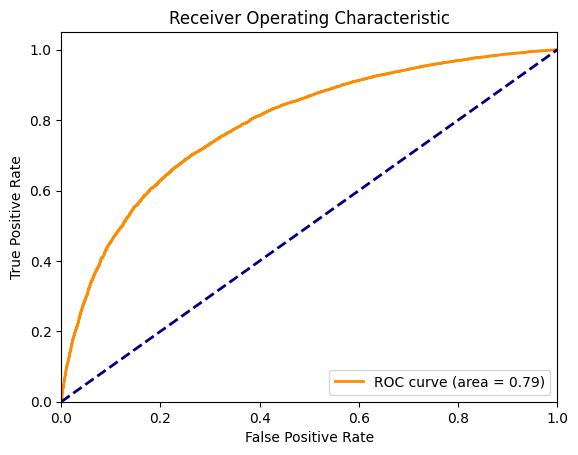

In [23]:
plot_roc_curve(all_data, 14)

we can see the ROC curve for best epoch. For all thresholds we can see the TPR and FPR values. We can see that the model is not able to distinguish between the classes very well. The curve is not very far from the diagonal line. So we can say that the model is not learning much from the data like we said before.

### I don't have enough ram to execute the all codes. So I ran the cod on google colab. Due to I forgot to write for test loader I compare the results of val loader. But If I wrote the code for test loader the presedure would be the same. Metrics would be different but the presedure would be the same.